In [ ]:
import pandas as pd
import ast
import os
import json
from pathlib import Path

In [ ]:
raw_data = Path('../data/raw')
processed_data = Path('../data/processed')

processed_data.mkdir(parents=True, exist_ok=True)

In [ ]:
# current_dir = os.getcwd()
# folder = r'C:\Users\astan\Downloads\6th sem\machine learning\movie-recommendation-project\data\raw'
# os.chdir(folder)

# credits = pd.read_csv('credits.csv')
# keywords = pd.read_csv('keywords.csv')
# links = pd.read_csv('links.csv')
# links_small = pd.read_csv('links_small.csv')
# movies_metadata = pd.read_csv('movies_metadata.csv')
# ratings = pd.read_csv('ratings.csv')
# ratings_small = pd.read_csv('ratings_small.csv')

# os.chdir(current_dir)

C:\Users\astan\AppData\Local\Temp\ipykernel_16808\737404976.py:9: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  movies_metadata = pd.read_csv('movies_metadata.csv')


In [ ]:
credits = pd.read_csv(raw_data / 'credits.csv')
keywords = pd.read_csv(raw_data / 'keywords.csv')
links = pd.read_csv(raw_data / 'links.csv')
links_small = pd.read_csv(raw_data / 'links_small.csv')
movies_metadata = pd.read_csv(raw_data / 'movies_metadata.csv')
ratings = pd.read_csv(raw_data / 'ratings.csv')
ratings_small = pd.read_csv(raw_data / 'ratings_small.csv')

In [3]:
movies_metadata.head(3)

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0


In [4]:
movies_metadata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45466 non-null  object 
 1   belongs_to_collection  4494 non-null   object 
 2   budget                 45466 non-null  object 
 3   genres                 45466 non-null  object 
 4   homepage               7782 non-null   object 
 5   id                     45466 non-null  object 
 6   imdb_id                45449 non-null  object 
 7   original_language      45455 non-null  object 
 8   original_title         45466 non-null  object 
 9   overview               44512 non-null  object 
 10  popularity             45461 non-null  object 
 11  poster_path            45080 non-null  object 
 12  production_companies   45463 non-null  object 
 13  production_countries   45463 non-null  object 
 14  release_date           45379 non-null  object 
 15  re

In [5]:
print('number of features: ', movies_metadata.shape[1])
print('number of datasamples: ', movies_metadata.shape[0])

number of features:  24
number of datasamples:  45466


In [6]:
print(movies_metadata.nunique())

adult                        5
belongs_to_collection     1698
budget                    1226
genres                    4069
homepage                  7673
id                       45436
imdb_id                  45417
original_language           92
original_title           43373
overview                 44307
popularity               44176
poster_path              45024
production_companies     22708
production_countries      2393
release_date             17336
revenue                   6863
runtime                    353
spoken_languages          1931
status                       6
tagline                  20283
title                    42277
video                        2
vote_average                92
vote_count                1820
dtype: int64


In [7]:
movies_metadata["adult"].value_counts() # not a usefull column 

adult
False                                                                                                                             45454
True                                                                                                                                  9
 - Written by Ørnås                                                                                                                   1
 Rune Balot goes to a casino connected to the October corporation to try to wrap up her case once and for all.                        1
 Avalanche Sharks tells the story of a bikini contest that turns into a horrifying affair when it is hit by a shark avalanche.        1
Name: count, dtype: int64

In [8]:
movies_metadata["original_language"].value_counts() # most movies are English

original_language
en       32269
fr        2438
it        1529
ja        1350
de        1080
         ...  
zu           1
qu           1
104.0        1
la           1
si           1
Name: count, Length: 92, dtype: int64

In [9]:
movies_metadata["production_countries"].value_counts() # not parsed, but yet most movies are produced by US

production_countries
[{'iso_3166_1': 'US', 'name': 'United States of America'}]                                                                                                          17851
[]                                                                                                                                                                   6282
[{'iso_3166_1': 'GB', 'name': 'United Kingdom'}]                                                                                                                     2238
[{'iso_3166_1': 'FR', 'name': 'France'}]                                                                                                                             1654
[{'iso_3166_1': 'JP', 'name': 'Japan'}]                                                                                                                              1356
                                                                                                                                 

In [10]:
movies_metadata["status"].value_counts() # most of them all released

status
Released           45014
Rumored              230
Post Production       98
In Production         20
Planned               15
Canceled               2
Name: count, dtype: int64

In [11]:
movies_metadata.isnull().sum()

adult                        0
belongs_to_collection    40972
budget                       0
genres                       0
homepage                 37684
id                           0
imdb_id                     17
original_language           11
original_title               0
overview                   954
popularity                   5
poster_path                386
production_companies         3
production_countries         3
release_date                87
revenue                      6
runtime                    263
spoken_languages             6
status                      87
tagline                  25054
title                        6
video                        6
vote_average                 6
vote_count                   6
dtype: int64

In [12]:
# adult                        useless
# belongs_to_collection        useless
# budget                       useless
# genres                       usefull*
# homepage                     useless
# id                           -*
# imdb_id                      we can join them later
# original_language            keeping it for now but en is probably too biased* 
# original_title               usefull*
# overview                     usefull*
# popularity                   usefull*
# poster_path                  usefull*
# production_companies         usefull*
# production_countries         keeping it for now but us is probably too biased*
# release_date                 usefull*
# revenue                      useless
# runtime                      useless
# spoken_languages             useless
# status                       useless
# tagline                      contains many null values but keeping it*
# title                        we are using original_title, so..
# video                        useless
# vote_average                 usefull*
# vote_count                   usefull*

In [13]:
movies_metadata = movies_metadata[["genres", "id", "original_language", "original_title", "overview", "popularity", "poster_path", "production_companies", "production_countries", "release_date",
                                   "tagline", "vote_average", "vote_count"]]

In [14]:
movies_metadata.head(3)

,genres,id,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,tagline,vote_average,vote_count
0,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",862,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",21.946943,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,"[{'name': 'Pixar Animation Studios', 'id': 3}]","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-10-30,NaN,7.7,5415.0
1,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",8844,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,/vzmL6fP7aPKNKPRTFnZmiUfciyV.jpg,"[{'name': 'TriStar Pictures', 'id': 559}, {'na...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-15,Roll the dice and unleash the excitement!,6.9,2413.0
2,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",15602,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,11.7129,/6ksm1sjKMFLbO7UY2i6G1ju9SML.jpg,"[{'name': 'Warner Bros.', 'id': 6194}, {'name'...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-22,Still Yelling. Still Fighting. Still Ready for...,6.5,92.0


In [15]:
movies_metadata["tagline"].fillna("unknown", inplace=True)

C:\Users\astan\AppData\Local\Temp\ipykernel_16808\32760742.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  movies_metadata["tagline"].fillna("unknown", inplace=True)


In [16]:
movies_metadata.isnull().sum()

genres                    0
id                        0
original_language        11
original_title            0
overview                954
popularity                5
poster_path             386
production_companies      3
production_countries      3
release_date             87
tagline                   0
vote_average              6
vote_count                6
dtype: int64

In [17]:
movies_metadata.dropna(inplace=True)

In [18]:
movies_metadata.isnull().sum()

genres                  0
id                      0
original_language       0
original_title          0
overview                0
popularity              0
poster_path             0
production_companies    0
production_countries    0
release_date            0
tagline                 0
vote_average            0
vote_count              0
dtype: int64

In [19]:
movies_metadata.shape

(44118, 13)

In [20]:
movies_metadata.duplicated().sum()

13

In [21]:
movies_metadata.drop_duplicates(inplace=True)

In [22]:
movies_metadata.shape

(44105, 13)

In [23]:
# moving to credis..
credits.head(3)

,cast,crew,id
0,"[{'cast_id': 14, 'character': 'Woody (voice)',...","[{'credit_id': '52fe4284c3a36847f8024f49', 'de...",862
1,"[{'cast_id': 1, 'character': 'Alan Parrish', '...","[{'credit_id': '52fe44bfc3a36847f80a7cd1', 'de...",8844
2,"[{'cast_id': 2, 'character': 'Max Goldman', 'c...","[{'credit_id': '52fe466a9251416c75077a89', 'de...",15602


In [24]:
credits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45476 entries, 0 to 45475
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   cast    45476 non-null  object
 1   crew    45476 non-null  object
 2   id      45476 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 1.0+ MB


In [25]:
credits.shape

(45476, 3)

In [26]:
credits.isnull().sum()

cast    0
crew    0
id      0
dtype: int64

In [27]:
credits.duplicated().sum()

37

In [28]:
credits.drop_duplicates(inplace=True)

In [29]:
credits.shape

(45439, 3)

In [30]:
# moving to keywords
keywords.head(3)

,id,keywords
0,862,"[{'id': 931, 'name': 'jealousy'}, {'id': 4290,..."
1,8844,"[{'id': 10090, 'name': 'board game'}, {'id': 1..."
2,15602,"[{'id': 1495, 'name': 'fishing'}, {'id': 12392..."


In [31]:
keywords.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46419 entries, 0 to 46418
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        46419 non-null  int64 
 1   keywords  46419 non-null  object
dtypes: int64(1), object(1)
memory usage: 725.4+ KB


In [32]:
keywords.shape

(46419, 2)

In [33]:
keywords.isnull().sum()

id          0
keywords    0
dtype: int64

In [34]:
keywords.duplicated().sum()

987

In [35]:
keywords.drop_duplicates(inplace=True)

In [36]:
keywords.shape

(45432, 2)

In [37]:
# converting id of metadata to int
movies_metadata["id"] = movies_metadata["id"].astype(int)

In [38]:
movies_metadata.info()

<class 'pandas.core.frame.DataFrame'>
Index: 44105 entries, 0 to 45465
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   genres                44105 non-null  object 
 1   id                    44105 non-null  int32  
 2   original_language     44105 non-null  object 
 3   original_title        44105 non-null  object 
 4   overview              44105 non-null  object 
 5   popularity            44105 non-null  object 
 6   poster_path           44105 non-null  object 
 7   production_companies  44105 non-null  object 
 8   production_countries  44105 non-null  object 
 9   release_date          44105 non-null  object 
 10  tagline               44105 non-null  object 
 11  vote_average          44105 non-null  float64
 12  vote_count            44105 non-null  float64
dtypes: float64(2), int32(1), object(10)
memory usage: 4.5+ MB


In [39]:
# also converting popularity 
movies_metadata["popularity"] = movies_metadata["popularity"].astype(float)

In [40]:
movies_metadata.info()

<class 'pandas.core.frame.DataFrame'>
Index: 44105 entries, 0 to 45465
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   genres                44105 non-null  object 
 1   id                    44105 non-null  int32  
 2   original_language     44105 non-null  object 
 3   original_title        44105 non-null  object 
 4   overview              44105 non-null  object 
 5   popularity            44105 non-null  float64
 6   poster_path           44105 non-null  object 
 7   production_companies  44105 non-null  object 
 8   production_countries  44105 non-null  object 
 9   release_date          44105 non-null  object 
 10  tagline               44105 non-null  object 
 11  vote_average          44105 non-null  float64
 12  vote_count            44105 non-null  float64
dtypes: float64(3), int32(1), object(9)
memory usage: 4.5+ MB


In [41]:
BASE_URL = "https://image.tmdb.org/t/p/w500"
movies_metadata["poster_url"] = BASE_URL + movies_metadata["poster_path"].astype(str)

In [42]:
movies_metadata["release_date"]

0        1995-10-30
1        1995-12-15
2        1995-12-22
3        1995-12-22
4        1995-02-10
            ...    
45460    1991-05-13
45462    2011-11-17
45463    2003-08-01
45464    1917-10-21
45465    2017-06-09
Name: release_date, Length: 44105, dtype: object

In [43]:
movies_metadata["release_year"] = movies_metadata["release_date"].apply(lambda x: int(x.split("-")[0]))
movies_metadata["release_year"]

0        1995
1        1995
2        1995
3        1995
4        1995
         ... 
45460    1991
45462    2011
45463    2003
45464    1917
45465    2017
Name: release_year, Length: 44105, dtype: int64

In [44]:
movies_metadata = movies_metadata.drop("release_date", axis=1)

In [45]:
movies_metadata.head(10)

,genres,id,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,tagline,vote_average,vote_count,poster_url,release_year
0,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",862,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",21.946943,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,"[{'name': 'Pixar Animation Studios', 'id': 3}]","[{'iso_3166_1': 'US', 'name': 'United States o...",unknown,7.7,5415.0,https://image.tmdb.org/t/p/w500/rhIRbceoE9lR4v...,1995
1,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",8844,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,/vzmL6fP7aPKNKPRTFnZmiUfciyV.jpg,"[{'name': 'TriStar Pictures', 'id': 559}, {'na...","[{'iso_3166_1': 'US', 'name': 'United States o...",Roll the dice and unleash the excitement!,6.9,2413.0,https://image.tmdb.org/t/p/w500/vzmL6fP7aPKNKP...,1995
2,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",15602,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,11.712900,/6ksm1sjKMFLbO7UY2i6G1ju9SML.jpg,"[{'name': 'Warner Bros.', 'id': 6194}, {'name'...","[{'iso_3166_1': 'US', 'name': 'United States o...",Still Yelling. Still Fighting. Still Ready for...,6.5,92.0,https://image.tmdb.org/t/p/w500/6ksm1sjKMFLbO7...,1995
3,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",31357,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",3.859495,/16XOMpEaLWkrcPqSQqhTmeJuqQl.jpg,[{'name': 'Twentieth Century Fox Film Corporat...,"[{'iso_3166_1': 'US', 'name': 'United States o...",Friends are the people who let you be yourself...,6.1,34.0,https://image.tmdb.org/t/p/w500/16XOMpEaLWkrcP...,1995
4,"[{'id': 35, 'name': 'Comedy'}]",11862,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,8.387519,/e64sOI48hQXyru7naBFyssKFxVd.jpg,"[{'name': 'Sandollar Productions', 'id': 5842}...","[{'iso_3166_1': 'US', 'name': 'United States o...",Just When His World Is Back To Normal... He's ...,5.7,173.0,https://image.tmdb.org/t/p/w500/e64sOI48hQXyru...,1995
5,"[{'id': 28, 'name': 'Action'}, {'id': 80, 'nam...",949,en,Heat,"Obsessive master thief, Neil McCauley leads a ...",17.924927,/zMyfPUelumio3tiDKPffaUpsQTD.jpg,"[{'name': 'Regency Enterprises', 'id': 508}, {...","[{'iso_3166_1': 'US', 'name': 'United States o...",A Los Angeles Crime Saga,7.7,1886.0,https://image.tmdb.org/t/p/w500/zMyfPUelumio3t...,1995
6,"[{'id': 35, 'name': 'Comedy'}, {'id': 10749, '...",11860,en,Sabrina,An ugly duckling having undergone a remarkable...,6.677277,/jQh15y5YB7bWz1NtffNZmRw0s9D.jpg,"[{'name': 'Paramount Pictures', 'id': 4}, {'na...","[{'iso_3166_1': 'DE', 'name': 'Germany'}, {'is...",You are cordially invited to the most surprisi...,6.2,141.0,https://image.tmdb.org/t/p/w500/jQh15y5YB7bWz1...,1995
7,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",45325,en,Tom and Huck,"A mischievous young boy, Tom Sawyer, witnesses...",2.561161,/sGO5Qa55p7wTu7FJcX4H4xIVKvS.jpg,"[{'name': 'Walt Disney Pictures', 'id': 2}]","[{'iso_3166_1': 'US', 'name': 'United States o...",The Original Bad Boys.,5.4,45.0,https://image.tmdb.org/t/p/w500/sGO5Qa55p7wTu7...,1995
8,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",9091,en,Sudden Death,International action superstar Jean Claude Van...,5.231580,/eoWvKD60lT95Ss1MYNgVExpo5iU.jpg,"[{'name': 'Universal Pictures', 'id': 33}, {'n...","[{'iso_3166_1': 'US', 'name': 'United States o...",Terror goes into overtime.,5.5,174.0,https://image.tmdb.org/t/p/w500/eoWvKD60lT95Ss...,1995
9,"[{'id': 12, 'name': 'Adventure'}, {'id': 28, '...",710,en,GoldenEye,James Bond must unmask the mysterious head of ...,14.686036,/5c0ovjT41KnYIHYuF4AWsTe3sKh.jpg,"[{'name': 'United Artists', 'id': 60}, {'name'...","[{'iso_3166_1': 'GB', 'name': 'United Kingdom'...",No limits. No fears. No substitutes.,6.6,1194.0,https://image.tmdb.org/t/p/w500/5c0ovjT41KnYIH...,1995


<Axes: >

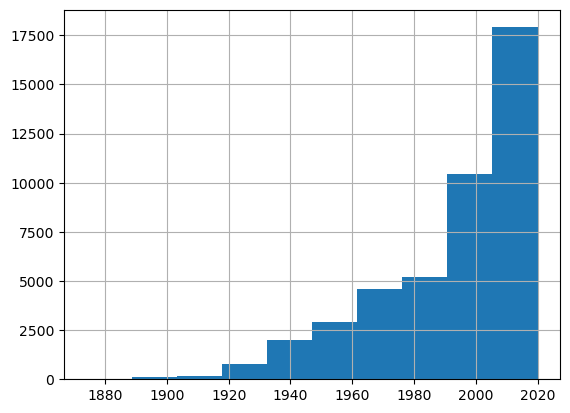

In [46]:
movies_metadata["release_year"].hist()

In [47]:
movies_metadata["release_year"] 

0        1995
1        1995
2        1995
3        1995
4        1995
         ... 
45460    1991
45462    2011
45463    2003
45464    1917
45465    2017
Name: release_year, Length: 44105, dtype: int64

In [48]:
# using release year as the decade the movie was produced in (bining)
def get_dacade(year):
    decade = (year // 10) * 10
    return decade

In [49]:
movies_metadata["release_decade"] = get_dacade(movies_metadata["release_year"])

In [50]:
movies_metadata["release_decade"]

0        1990
1        1990
2        1990
3        1990
4        1990
         ... 
45460    1990
45462    2010
45463    2000
45464    1910
45465    2010
Name: release_decade, Length: 44105, dtype: int64

In [51]:
movies_metadata["release_decade"][15276]

1960

In [52]:
movies_metadata["release_year"][15276]

1964

In [53]:
movies_metadata = movies_metadata.drop("release_year", axis=1)

In [54]:
movies_metadata.head(3)

,genres,id,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,tagline,vote_average,vote_count,poster_url,release_decade
0,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",862,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",21.946943,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,"[{'name': 'Pixar Animation Studios', 'id': 3}]","[{'iso_3166_1': 'US', 'name': 'United States o...",unknown,7.7,5415.0,https://image.tmdb.org/t/p/w500/rhIRbceoE9lR4v...,1990
1,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",8844,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,/vzmL6fP7aPKNKPRTFnZmiUfciyV.jpg,"[{'name': 'TriStar Pictures', 'id': 559}, {'na...","[{'iso_3166_1': 'US', 'name': 'United States o...",Roll the dice and unleash the excitement!,6.9,2413.0,https://image.tmdb.org/t/p/w500/vzmL6fP7aPKNKP...,1990
2,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",15602,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,11.712900,/6ksm1sjKMFLbO7UY2i6G1ju9SML.jpg,"[{'name': 'Warner Bros.', 'id': 6194}, {'name'...","[{'iso_3166_1': 'US', 'name': 'United States o...",Still Yelling. Still Fighting. Still Ready for...,6.5,92.0,https://image.tmdb.org/t/p/w500/6ksm1sjKMFLbO7...,1990


In [55]:
print("shape before merging:")
print(movies_metadata.shape)

shape before merging:
(44105, 14)


In [56]:
# merging datasets
# movies and keywords
initial_merged = pd.merge(movies_metadata, keywords, on="id")

In [57]:
print("shape after merging movies and keywords:")
print(initial_merged.shape)

shape after merging movies and keywords:
(44104, 15)


In [58]:
# merging with credits
merged_data = pd.merge(initial_merged, credits, on="id")

In [59]:
print("shape after merging movies and keywords and credits:")
print(merged_data.shape)

shape after merging movies and keywords and credits:
(44117, 17)


In [60]:
merged_data.head(3)

,genres,id,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,tagline,vote_average,vote_count,poster_url,release_decade,keywords,cast,crew
0,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",862,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",21.946943,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,"[{'name': 'Pixar Animation Studios', 'id': 3}]","[{'iso_3166_1': 'US', 'name': 'United States o...",unknown,7.7,5415.0,https://image.tmdb.org/t/p/w500/rhIRbceoE9lR4v...,1990,"[{'id': 931, 'name': 'jealousy'}, {'id': 4290,...","[{'cast_id': 14, 'character': 'Woody (voice)',...","[{'credit_id': '52fe4284c3a36847f8024f49', 'de..."
1,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",8844,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,/vzmL6fP7aPKNKPRTFnZmiUfciyV.jpg,"[{'name': 'TriStar Pictures', 'id': 559}, {'na...","[{'iso_3166_1': 'US', 'name': 'United States o...",Roll the dice and unleash the excitement!,6.9,2413.0,https://image.tmdb.org/t/p/w500/vzmL6fP7aPKNKP...,1990,"[{'id': 10090, 'name': 'board game'}, {'id': 1...","[{'cast_id': 1, 'character': 'Alan Parrish', '...","[{'credit_id': '52fe44bfc3a36847f80a7cd1', 'de..."
2,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",15602,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,11.712900,/6ksm1sjKMFLbO7UY2i6G1ju9SML.jpg,"[{'name': 'Warner Bros.', 'id': 6194}, {'name'...","[{'iso_3166_1': 'US', 'name': 'United States o...",Still Yelling. Still Fighting. Still Ready for...,6.5,92.0,https://image.tmdb.org/t/p/w500/6ksm1sjKMFLbO7...,1990,"[{'id': 1495, 'name': 'fishing'}, {'id': 12392...","[{'cast_id': 2, 'character': 'Max Goldman', 'c...","[{'credit_id': '52fe466a9251416c75077a89', 'de..."


In [61]:
from ast import literal_eval
# literal eval converts any string to its actual type

def convert(obj):

    L = []

    for i in literal_eval(obj):
        L.append(i["name"])

    return L

In [62]:
merged_data["genres"] = merged_data["genres"].apply(convert)

In [63]:
merged_data["production_companies"] = merged_data["production_companies"].apply(convert)

In [64]:
merged_data["production_countries"] = merged_data["production_countries"].apply(convert)

In [65]:
merged_data["keywords"] = merged_data["keywords"].apply(convert)

In [66]:
merged_data.head(3)

,genres,id,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,tagline,vote_average,vote_count,poster_url,release_decade,keywords,cast,crew
0,"[Animation, Comedy, Family]",862,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",21.946943,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,[Pixar Animation Studios],[United States of America],unknown,7.7,5415.0,https://image.tmdb.org/t/p/w500/rhIRbceoE9lR4v...,1990,"[jealousy, toy, boy, friendship, friends, riva...","[{'cast_id': 14, 'character': 'Woody (voice)',...","[{'credit_id': '52fe4284c3a36847f8024f49', 'de..."
1,"[Adventure, Fantasy, Family]",8844,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,/vzmL6fP7aPKNKPRTFnZmiUfciyV.jpg,"[TriStar Pictures, Teitler Film, Interscope Co...",[United States of America],Roll the dice and unleash the excitement!,6.9,2413.0,https://image.tmdb.org/t/p/w500/vzmL6fP7aPKNKP...,1990,"[board game, disappearance, based on children'...","[{'cast_id': 1, 'character': 'Alan Parrish', '...","[{'credit_id': '52fe44bfc3a36847f80a7cd1', 'de..."
2,"[Romance, Comedy]",15602,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,11.712900,/6ksm1sjKMFLbO7UY2i6G1ju9SML.jpg,"[Warner Bros., Lancaster Gate]",[United States of America],Still Yelling. Still Fighting. Still Ready for...,6.5,92.0,https://image.tmdb.org/t/p/w500/6ksm1sjKMFLbO7...,1990,"[fishing, best friend, duringcreditsstinger, o...","[{'cast_id': 2, 'character': 'Max Goldman', 'c...","[{'credit_id': '52fe466a9251416c75077a89', 'de..."


In [67]:
# we only use the first 3 cast members
def convert_cast(obj):

    L = []
    counter = 0

    for i in literal_eval(obj):
        if counter != 3:
            L.append(i["name"])
            counter += 1

    return L

In [68]:
merged_data["cast"] = merged_data["cast"].apply(convert_cast)

In [69]:
# from crew, we only use director name
def convert_crew(obj):
    for i in literal_eval(obj):
        if i["job"] == "Director":
            return i["name"]

In [70]:
merged_data["director"] = merged_data["crew"].apply(convert_crew)

In [71]:
merged_data.head(3)

,genres,id,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,tagline,vote_average,vote_count,poster_url,release_decade,keywords,cast,crew,director
0,"[Animation, Comedy, Family]",862,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",21.946943,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,[Pixar Animation Studios],[United States of America],unknown,7.7,5415.0,https://image.tmdb.org/t/p/w500/rhIRbceoE9lR4v...,1990,"[jealousy, toy, boy, friendship, friends, riva...","[Tom Hanks, Tim Allen, Don Rickles]","[{'credit_id': '52fe4284c3a36847f8024f49', 'de...",John Lasseter
1,"[Adventure, Fantasy, Family]",8844,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,/vzmL6fP7aPKNKPRTFnZmiUfciyV.jpg,"[TriStar Pictures, Teitler Film, Interscope Co...",[United States of America],Roll the dice and unleash the excitement!,6.9,2413.0,https://image.tmdb.org/t/p/w500/vzmL6fP7aPKNKP...,1990,"[board game, disappearance, based on children'...","[Robin Williams, Jonathan Hyde, Kirsten Dunst]","[{'credit_id': '52fe44bfc3a36847f80a7cd1', 'de...",Joe Johnston
2,"[Romance, Comedy]",15602,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,11.712900,/6ksm1sjKMFLbO7UY2i6G1ju9SML.jpg,"[Warner Bros., Lancaster Gate]",[United States of America],Still Yelling. Still Fighting. Still Ready for...,6.5,92.0,https://image.tmdb.org/t/p/w500/6ksm1sjKMFLbO7...,1990,"[fishing, best friend, duringcreditsstinger, o...","[Walter Matthau, Jack Lemmon, Ann-Margret]","[{'credit_id': '52fe466a9251416c75077a89', 'de...",Howard Deutch


In [72]:
merged_data = merged_data.drop("crew", axis=1)

In [73]:
merged_data.head(3)

,genres,id,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,tagline,vote_average,vote_count,poster_url,release_decade,keywords,cast,director
0,"[Animation, Comedy, Family]",862,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",21.946943,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,[Pixar Animation Studios],[United States of America],unknown,7.7,5415.0,https://image.tmdb.org/t/p/w500/rhIRbceoE9lR4v...,1990,"[jealousy, toy, boy, friendship, friends, riva...","[Tom Hanks, Tim Allen, Don Rickles]",John Lasseter
1,"[Adventure, Fantasy, Family]",8844,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,/vzmL6fP7aPKNKPRTFnZmiUfciyV.jpg,"[TriStar Pictures, Teitler Film, Interscope Co...",[United States of America],Roll the dice and unleash the excitement!,6.9,2413.0,https://image.tmdb.org/t/p/w500/vzmL6fP7aPKNKP...,1990,"[board game, disappearance, based on children'...","[Robin Williams, Jonathan Hyde, Kirsten Dunst]",Joe Johnston
2,"[Romance, Comedy]",15602,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,11.712900,/6ksm1sjKMFLbO7UY2i6G1ju9SML.jpg,"[Warner Bros., Lancaster Gate]",[United States of America],Still Yelling. Still Fighting. Still Ready for...,6.5,92.0,https://image.tmdb.org/t/p/w500/6ksm1sjKMFLbO7...,1990,"[fishing, best friend, duringcreditsstinger, o...","[Walter Matthau, Jack Lemmon, Ann-Margret]",Howard Deutch


In [74]:
merged_data.isnull().sum()

genres                    0
id                        0
original_language         0
original_title            0
overview                  0
popularity                0
poster_path               0
production_companies      0
production_countries      0
tagline                   0
vote_average              0
vote_count                0
poster_url                0
release_decade            0
keywords                  0
cast                      0
director                671
dtype: int64

In [75]:
merged_data.shape

(44117, 17)

In [76]:
merged_data.dropna(inplace=True)

In [77]:
merged_data.isnull().sum()

genres                  0
id                      0
original_language       0
original_title          0
overview                0
popularity              0
poster_path             0
production_companies    0
production_countries    0
tagline                 0
vote_average            0
vote_count              0
poster_url              0
release_decade          0
keywords                0
cast                    0
director                0
dtype: int64

In [78]:
merged_data["id"].duplicated().sum()

30

In [79]:
merged_data.shape

(43446, 17)

In [80]:
# merging with links

In [81]:
links.head(3)

,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0


In [82]:
links.shape

(45843, 3)

In [83]:
links.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45843 entries, 0 to 45842
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   movieId  45843 non-null  int64  
 1   imdbId   45843 non-null  int64  
 2   tmdbId   45624 non-null  float64
dtypes: float64(1), int64(2)
memory usage: 1.0 MB


In [84]:
links.isnull().sum()

movieId      0
imdbId       0
tmdbId     219
dtype: int64

In [85]:
links = links.dropna(subset=["movieId", "tmdbId"])

In [86]:
links["tmdbId"] = links["tmdbId"].astype(int)

In [87]:
links.duplicated().sum()

0

In [88]:
# renaming id to tmdbId
merged_data.rename(columns={"id": "tmdbId"}, inplace=True)
merged_data.head(3)

,genres,tmdbId,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,tagline,vote_average,vote_count,poster_url,release_decade,keywords,cast,director
0,"[Animation, Comedy, Family]",862,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",21.946943,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,[Pixar Animation Studios],[United States of America],unknown,7.7,5415.0,https://image.tmdb.org/t/p/w500/rhIRbceoE9lR4v...,1990,"[jealousy, toy, boy, friendship, friends, riva...","[Tom Hanks, Tim Allen, Don Rickles]",John Lasseter
1,"[Adventure, Fantasy, Family]",8844,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,/vzmL6fP7aPKNKPRTFnZmiUfciyV.jpg,"[TriStar Pictures, Teitler Film, Interscope Co...",[United States of America],Roll the dice and unleash the excitement!,6.9,2413.0,https://image.tmdb.org/t/p/w500/vzmL6fP7aPKNKP...,1990,"[board game, disappearance, based on children'...","[Robin Williams, Jonathan Hyde, Kirsten Dunst]",Joe Johnston
2,"[Romance, Comedy]",15602,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,11.712900,/6ksm1sjKMFLbO7UY2i6G1ju9SML.jpg,"[Warner Bros., Lancaster Gate]",[United States of America],Still Yelling. Still Fighting. Still Ready for...,6.5,92.0,https://image.tmdb.org/t/p/w500/6ksm1sjKMFLbO7...,1990,"[fishing, best friend, duringcreditsstinger, o...","[Walter Matthau, Jack Lemmon, Ann-Margret]",Howard Deutch


In [89]:
merged_data["tmdbId"].duplicated().sum()

30

In [90]:
merged_data[merged_data.duplicated(subset=["tmdbId"], keep=False)].sort_values("tmdbId")

,genres,tmdbId,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,tagline,vote_average,vote_count,poster_url,release_decade,keywords,cast,director
33142,"[Comedy, Crime, Drama, Romance, Thriller]",4912,en,Confessions of a Dangerous Mind,"Television made him famous, but his biggest hi...",7.645827,/o3Im9nPLAgtlw1j2LtpMebAotSe.jpg,"[Miramax Films, Allied Filmmakers, Mad Chance]",[United States of America],Some things are better left top secret.,6.6,281.0,https://image.tmdb.org/t/p/w500/o3Im9nPLAgtlw1...,2000,"[microfilm, biography, silencer, intrigue]","[Sam Rockwell, Drew Barrymore, Julia Roberts]",George Clooney
33141,"[Comedy, Crime, Drama, Romance, Thriller]",4912,en,Confessions of a Dangerous Mind,"Television made him famous, but his biggest hi...",7.645827,/o3Im9nPLAgtlw1j2LtpMebAotSe.jpg,"[Miramax Films, Allied Filmmakers, Mad Chance]",[United States of America],Some things are better left top secret.,6.6,281.0,https://image.tmdb.org/t/p/w500/o3Im9nPLAgtlw1...,2000,"[microfilm, biography, silencer, intrigue]","[Sam Rockwell, Drew Barrymore, Julia Roberts]",George Clooney
5824,"[Comedy, Crime, Drama, Romance, Thriller]",4912,en,Confessions of a Dangerous Mind,"Television made him famous, but his biggest hi...",11.331072,/o3Im9nPLAgtlw1j2LtpMebAotSe.jpg,"[Miramax Films, Allied Filmmakers, Mad Chance]",[United States of America],Some things are better left top secret.,6.6,281.0,https://image.tmdb.org/t/p/w500/o3Im9nPLAgtlw1...,2000,"[microfilm, biography, silencer, intrigue]","[Sam Rockwell, Drew Barrymore, Julia Roberts]",George Clooney
5825,"[Comedy, Crime, Drama, Romance, Thriller]",4912,en,Confessions of a Dangerous Mind,"Television made him famous, but his biggest hi...",11.331072,/o3Im9nPLAgtlw1j2LtpMebAotSe.jpg,"[Miramax Films, Allied Filmmakers, Mad Chance]",[United States of America],Some things are better left top secret.,6.6,281.0,https://image.tmdb.org/t/p/w500/o3Im9nPLAgtlw1...,2000,"[microfilm, biography, silencer, intrigue]","[Sam Rockwell, Drew Barrymore, Julia Roberts]",George Clooney
43516,"[Adventure, Fantasy, Animation, Action, Family]",10991,ja,Pokémon 3: The Movie,When Molly Hale's sadness of her father's disa...,6.480376,/5ILjS6XB5deiHop8SXPsYxXWVPE.jpg,"[TV Tokyo, 4 Kids Entertainment, Nintendo, Pik...",[Japan],Pokémon: Spell of the Unknown,6.0,144.0,https://image.tmdb.org/t/p/w500/5ILjS6XB5deiHo...,2000,"[mountain, mountain village, friendship, based...","[Veronica Taylor, Rachael Lillis, Eric Stuart]",Michael Haigney
4079,"[Adventure, Fantasy, Animation, Action, Family]",10991,ja,Pokémon 3: The Movie,When Molly Hale's sadness of her father's disa...,10.264597,/5ILjS6XB5deiHop8SXPsYxXWVPE.jpg,"[TV Tokyo, 4 Kids Entertainment, Nintendo, Pik...",[Japan],Pokémon: Spell of the Unknown,6.0,143.0,https://image.tmdb.org/t/p/w500/5ILjS6XB5deiHo...,2000,"[mountain, mountain village, friendship, based...","[Veronica Taylor, Rachael Lillis, Eric Stuart]",Michael Haigney
43521,"[Adventure, Fantasy, Animation, Science Fictio...",12600,ja,劇場版ポケットモンスター セレビィ 時を越えた遭遇（であい）,"All your favorite Pokémon characters are back,...",6.080108,/bqL0PVHbQ8Jmw3Njcl38kW0CoeM.jpg,[],"[Japan, United States of America]",unknown,5.7,82.0,https://image.tmdb.org/t/p/w500/bqL0PVHbQ8Jmw3...,2000,"[sequel, pokémon, celebi]","[Veronica Taylor, Rachael Lillis, Maddie Blaus...",Kunihiko Yuyama
5497,"[Adventure, Fantasy, Animation, Science Fictio...",12600,ja,劇場版ポケットモンスター セレビィ 時を越えた遭遇（であい）,"All your favorite Pokémon characters are back,...",7.072301,/bqL0PVHbQ8Jmw3Njcl38kW0CoeM.jpg,[],"[Japan, United States of America]",unknown,5.7,82.0,https://image.tmdb.org/t/p/w500/bqL0PVHbQ8Jmw3...,2000,"[sequel, pokémon, celebi]","[Veronica Taylor, Rachael Lillis, Maddie Blaus...",Kunihiko Yuyama
15655,"[Drama, Comedy, Foreign]",13209,fa,Offside,"Since women are banned from soccer matches, Ir...",1.529879,/nfkOkpudNNIjRrf0mTFVoiGzHyc.jpg,[Jafar Panahi Film Productions],[Iran],unknown,6.7,27.0,https://

In [91]:
merged_data = merged_data.drop_duplicates(subset=['tmdbId'])
merged_data["tmdbId"].duplicated().sum()

0

In [92]:
print("Movies before join:")
print(merged_data.shape)

Movies before join:
(43416, 17)


In [93]:
merged_final = pd.merge(merged_data, links, how="inner", on="tmdbId")

In [94]:
merged_final.head(3)

,genres,tmdbId,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,tagline,vote_average,vote_count,poster_url,release_decade,keywords,cast,director,movieId,imdbId
0,"[Animation, Comedy, Family]",862,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",21.946943,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,[Pixar Animation Studios],[United States of America],unknown,7.7,5415.0,https://image.tmdb.org/t/p/w500/rhIRbceoE9lR4v...,1990,"[jealousy, toy, boy, friendship, friends, riva...","[Tom Hanks, Tim Allen, Don Rickles]",John Lasseter,1,114709
1,"[Adventure, Fantasy, Family]",8844,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,/vzmL6fP7aPKNKPRTFnZmiUfciyV.jpg,"[TriStar Pictures, Teitler Film, Interscope Co...",[United States of America],Roll the dice and unleash the excitement!,6.9,2413.0,https://image.tmdb.org/t/p/w500/vzmL6fP7aPKNKP...,1990,"[board game, disappearance, based on children'...","[Robin Williams, Jonathan Hyde, Kirsten Dunst]",Joe Johnston,2,113497
2,"[Romance, Comedy]",15602,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,11.712900,/6ksm1sjKMFLbO7UY2i6G1ju9SML.jpg,"[Warner Bros., Lancaster Gate]",[United States of America],Still Yelling. Still Fighting. Still Ready for...,6.5,92.0,https://image.tmdb.org/t/p/w500/6ksm1sjKMFLbO7...,1990,"[fishing, best friend, duringcreditsstinger, o...","[Walter Matthau, Jack Lemmon, Ann-Margret]",Howard Deutch,3,113228


In [95]:
print("Movies after join:")
print(merged_final.shape)

Movies after join:
(43446, 19)


In [96]:
merged_final.isnull().sum()

genres                  0
tmdbId                  0
original_language       0
original_title          0
overview                0
popularity              0
poster_path             0
production_companies    0
production_countries    0
tagline                 0
vote_average            0
vote_count              0
poster_url              0
release_decade          0
keywords                0
cast                    0
director                0
movieId                 0
imdbId                  0
dtype: int64

In [97]:
merged_final["tmdbId"].duplicated().sum()

30

In [98]:
merged_final = merged_final.drop_duplicates(subset=['tmdbId'])
merged_final["tmdbId"].duplicated().sum()

0

In [99]:
merged_final.shape

(43416, 19)

In [100]:
# creating tags

merged_final["release_decade"] = merged_final["release_decade"].apply(lambda x: f"{x}") # converting to an object

In [101]:
def ensure_list(x):
    if isinstance(x, list):
        return [str(i) for i in x]
    elif isinstance(x, str):
        # case where it looks like "['Animation', 'Comedy']"
        x = x.strip("[]").replace("'", "").split(",")
        return [i.strip() for i in x if i.strip()]
    else:
        return []

for col in ['genres', 'keywords', 'cast']:
    merged_final[col] = merged_final[col].apply(ensure_list)

In [102]:
def clean_data(x, drop_unknown=False):
    if isinstance(x, list):
        return " ".join([str(i) for i in x])  # join list into string
    elif isinstance(x, str):
        if drop_unknown and x.lower().strip() == "unknown": # drop "unknown" from tagline col
            return ""
        return x
    else:
        return ""  # handle NaN

In [103]:
merged_final['metatags'] = (
    merged_final['genres'].apply(clean_data) + " " +
    merged_final['overview'].apply(clean_data) + " " +
    merged_final['tagline'].apply(lambda x: clean_data(x, drop_unknown=True)) + " " +
    merged_final['release_decade'].astype(str) + " " +
    merged_final['keywords'].apply(clean_data) + " " +
    merged_final['cast'].apply(clean_data) + " " +
    merged_final['director'].apply(clean_data)
)

In [104]:
merged_final['metatags'][0]

"Animation Comedy Family Led by Woody, Andy's toys live happily in his room until Andy's birthday brings Buzz Lightyear onto the scene. Afraid of losing his place in Andy's heart, Woody plots against Buzz. But when circumstances separate Buzz and Woody from their owner, the duo eventually learns to put aside their differences.  1990 jealousy toy boy friendship friends rivalry boy next door new toy toy comes to life Tom Hanks Tim Allen Don Rickles John Lasseter"

In [105]:
merged_final['metatags'] = merged_final['metatags'].str.lower()

In [106]:
merged_final['metatags'][0]

"animation comedy family led by woody, andy's toys live happily in his room until andy's birthday brings buzz lightyear onto the scene. afraid of losing his place in andy's heart, woody plots against buzz. but when circumstances separate buzz and woody from their owner, the duo eventually learns to put aside their differences.  1990 jealousy toy boy friendship friends rivalry boy next door new toy toy comes to life tom hanks tim allen don rickles john lasseter"

In [107]:
# removing punctuation. keeping numbers
merged_final['metatags'] = merged_final['metatags'].str.replace(r'[^\w\s]', '', regex=True)
merged_final['metatags'][0]

'animation comedy family led by woody andys toys live happily in his room until andys birthday brings buzz lightyear onto the scene afraid of losing his place in andys heart woody plots against buzz but when circumstances separate buzz and woody from their owner the duo eventually learns to put aside their differences  1990 jealousy toy boy friendship friends rivalry boy next door new toy toy comes to life tom hanks tim allen don rickles john lasseter'

In [108]:
merged_final.head(3)

,genres,tmdbId,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,tagline,vote_average,vote_count,poster_url,release_decade,keywords,cast,director,movieId,imdbId,metatags
0,"[Animation, Comedy, Family]",862,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",21.946943,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,[Pixar Animation Studios],[United States of America],unknown,7.7,5415.0,https://image.tmdb.org/t/p/w500/rhIRbceoE9lR4v...,1990,"[jealousy, toy, boy, friendship, friends, riva...","[Tom Hanks, Tim Allen, Don Rickles]",John Lasseter,1,114709,animation comedy family led by woody andys toy...
1,"[Adventure, Fantasy, Family]",8844,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,/vzmL6fP7aPKNKPRTFnZmiUfciyV.jpg,"[TriStar Pictures, Teitler Film, Interscope Co...",[United States of America],Roll the dice and unleash the excitement!,6.9,2413.0,https://image.tmdb.org/t/p/w500/vzmL6fP7aPKNKP...,1990,"[board game, disappearance, based on children'...","[Robin Williams, Jonathan Hyde, Kirsten Dunst]",Joe Johnston,2,113497,adventure fantasy family when siblings judy an...
2,"[Romance, Comedy]",15602,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,11.712900,/6ksm1sjKMFLbO7UY2i6G1ju9SML.jpg,"[Warner Bros., Lancaster Gate]",[United States of America],Still Yelling. Still Fighting. Still Ready for...,6.5,92.0,https://image.tmdb.org/t/p/w500/6ksm1sjKMFLbO7...,1990,"[fishing, best friend, duringcreditsstinger, o...","[Walter Matthau, Jack Lemmon, Ann-Margret]",Howard Deutch,3,113228,romance comedy a family wedding reignites the ...


In [ ]:
processed_data = Path('../data/processed')

merged_final.to_csv(processed_data / 'movies_clean.csv', index=False)

In [112]:
# cleaning ratings.csv
ratings.head()

,userId,movieId,rating,timestamp
0,1,110,1.0,1425941529
1,1,147,4.5,1425942435
2,1,858,5.0,1425941523
3,1,1221,5.0,1425941546
4,1,1246,5.0,1425941556


In [113]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26024289 entries, 0 to 26024288
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  int64  
dtypes: float64(1), int64(3)
memory usage: 794.2 MB


In [114]:
ratings["datetime"] = pd.to_datetime(ratings["timestamp"], unit='s')
ratings["year"] = ratings["datetime"].dt.year
ratings["month"] = ratings["datetime"].dt.month

In [115]:
ratings.head()

,userId,movieId,rating,timestamp,datetime,year,month
0,1,110,1.0,1425941529,2015-03-09 22:52:09,2015,3
1,1,147,4.5,1425942435,2015-03-09 23:07:15,2015,3
2,1,858,5.0,1425941523,2015-03-09 22:52:03,2015,3
3,1,1221,5.0,1425941546,2015-03-09 22:52:26,2015,3
4,1,1246,5.0,1425941556,2015-03-09 22:52:36,2015,3


In [ ]:
ratings.isna().sum()

userId       0
movieId      0
rating       0
timestamp    0
datetime     0
year         0
month        0
dtype: int64

In [ ]:
ratings.duplicated().sum()

0

In [ ]:
ratings.shape

(26024289, 7)

In [ ]:
# current_dir = os.getcwd()
# folder = r'C:\Users\astan\Downloads\6th sem\machine learning\movie-recommendation-project\data\processed'
# os.chdir(folder)

# # saving the processed dataset (ratings)
# ratings.to_csv("ratings_clean.csv", index=False)

# os.chdir(current_dir)

In [ ]:
ratings.to_csv(processed_data / 'ratings_clean.csv', index=False)